In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import math

In [ ]:
from collections import Counter
from typing import Dict, List, Tuple, Union

In [ ]:
def gini(mas):
  _, counts = np.unique(mas, return_counts = True)
  proba = counts / len(mas)
  return np.sum(proba * (1 - proba))
def reg(mas):
  return np.var(mas)

def find_best_split(
    feature_vector: Union[np.ndarray, pd.DataFrame],
    target_vector: Union[np.ndarray, pd.Series],
    task: str = "classification",
    feature_type: str = "real"
) -> Tuple[np.ndarray, np.ndarray, float, float]:

    x = np.array(feature_vector).flatten()
    y = np.array(target_vector).flatten()
    n = len(x)
    if task == 'classification':
      H = gini
    else:
      H = reg
    H_p = H(y)
    if feature_type == 'real':
      x_unique = np.unique(x)
      thresholds = (x_unique[:-1] + x_unique[1:])/2
    else:
      thresholds = np.unique(x)
    val_tresh = []
    val_Q = []
    for t in thresholds:
      if feature_type == 'real':
        y_l = y[x <= t]
        y_r = y[x > t]
      else:
        y_l = y[x == t]
        y_r = y[x != t]
      if len(y_l) == 0 or len(y_r) == 0:
        continue
      H_l, H_r = H(y_l), H(y_r)
      Q = H_p - (len(y_l)/n)*H_l - (len(y_r)/n)*H_r
      val_Q.append(Q)
      val_tresh.append(t)
    val_tresh = np.array(val_tresh)
    val_Q = np.array(val_Q)
    if len(val_Q) == 0:
        return np.array([]), np.array([]), None, None
    maxi = np.max(val_Q)
    for i in range(len(val_Q)):
      if val_Q[i] == maxi:
        threshold_best = val_tresh[i]
        gini_best = maxi
        break
    return val_tresh, val_Q, threshold_best, gini_best

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
data = fetch_california_housing()
X = pd.DataFrame(data=data["data"], columns=data["feature_names"])
y = data["target"]
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894])

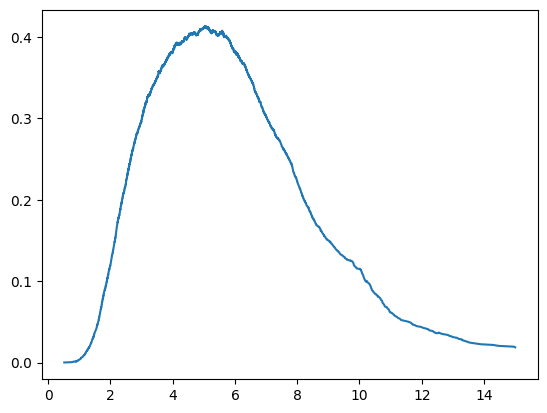

In [ ]:
T, Q, best_t, best_q = find_best_split(X['MedInc'], y, 'regression', 'real')
plt.plot(T, Q)
plt.show()


Лучший предикат первой вершины решающего дерева

In [ ]:
data['feature_names']

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [ ]:
maxi_q = -1
ans = ''
ans_t = 0
for feature in data['feature_names']:
  T, Q, best_t, best_q = find_best_split(X[feature], y, 'regression', 'real')
  if best_q > maxi_q:
    maxi_q = best_q
    ans = feature
    ans_t = best_t
print(ans, ans_t, maxi_q)


MedInc 5.03515 0.4127513862016769


In [ ]:
class DecisionTree:

    def __init__(
        self,
        feature_types: Union[List[str], np.ndarray],
        max_depth: int = None,
        min_samples_split: int = None,
        min_samples_leaf: int = None,
        task: str = "classification"
    ) -> None:

        if np.any(list(map(lambda x: x != "real" and x != "categorical", feature_types))):
            raise ValueError("There is unknown feature type")

        # В этой переменной будем хранить узлы решающего дерева. Каждая вершина хранит в себе идентификатор того,
        # является ли она листовой. Листовые вершины хранят значение класса для предсказания, нелистовые - правого и
        # левого детей (поддеревья для продолжения процедуры предсказания)
        self._tree = {}

        self._feature_types = feature_types

        self._max_depth = max_depth
        self._min_samples_split = min_samples_split
        self._min_samples_leaf = min_samples_leaf
        self.task = task

        self._feature_importances = {}


    def _fit_node(
        self,
        sub_X: np.ndarray,
        sub_y: np.ndarray,
        node: dict
    ) -> None:

        if np.all(sub_y == sub_y[0]):
            node["type"] = "terminal"
            node["class"] = sub_y[0]
            return

        feature_best, threshold_best, gini_best, split = None, None, None, None
        for feature in range(sub_X.shape[1]):
            feature_type = self._feature_types[feature]
            categories_map = {}

            if feature_type == "real":
                feature_vector = sub_X[:, feature]
            elif feature_type == "categorical":
                feature_vector = sub_X[:, feature]

            _, _, threshold, gini = find_best_split(feature_vector, sub_y, self.task, feature_type)

            if gini is not None and (gini_best is None or gini > gini_best):
                feature_best = feature
                gini_best = gini
                threshold_best = threshold

                if feature_type == "real":
                    threshold_best = threshold
                    split = feature_vector <= threshold
                elif feature_type == "categorical":
                    threshold_best = threshold
                    split = feature_vector == threshold
                else:
                    raise ValueError

        if feature_best is None:
            node["type"] = "terminal"
            node["class"] = Counter(sub_y).most_common(1)[0][0]
            return

        node["type"] = "nonterminal"

        node["feature_split"] = feature_best
        if self._feature_types[feature_best] == "real":
            node["threshold"] = threshold_best
        elif self._feature_types[feature_best] == "categorical":
            node["category_split"] = threshold_best
        else:
            raise ValueError

        node["left_child"], node["right_child"] = {}, {}
        self._fit_node(sub_X[split], sub_y[split], node["left_child"])
        self._fit_node(sub_X[np.logical_not(split)], sub_y[np.logical_not(split)], node["right_child"])

    def _predict_node(self, x: np.ndarray, node: dict) -> int:
        """
        Предсказание начинается с корневой вершины дерева и рекурсивно идёт в левое или правое поддерево в зависимости от значения
        предиката на объекте. Листовая вершина возвращает предсказание.
        :param x: np.array, элемент выборки
        :param node: dict, вершина дерева
        """
        if node['type'] == 'terminal':
          return node['class']
        feature_ind = node['feature_split']
        feature_type = self._feature_types[feature_ind]
        feature_val = x[feature_ind]
        if feature_type == 'real':
          if feature_val <= node['threshold']:
            return self._predict_node(x, node['left_child'])
          else:
            return self._predict_node(x, node['right_child'])
        else:
          if feature_val == node['category_split']:
            return self._predict_node(x, node['left_child'])
          else:
            return self._predict_node(x, node['right_child'])

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self._fit_node(X, y, self._tree)

    def predict(self, X: np.ndarray) -> np.ndarray:
        predicted = []
        for x in X:
            predicted.append(self._predict_node(x, self._tree))

        return np.array(predicted)

In [ ]:
!wget https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/homework/homework03/students.csv .

--2026-04-17 17:03:12--  https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/homework/homework03/students.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7794 (7.6K) [text/plain]
Saving to: ‘students.csv’

students.csv        100%[===================>]   7.61K  --.-KB/s    in 0s      

2026-04-17 17:03:13 (53.2 MB/s) - ‘students.csv’ saved [7794/7794]

--2026-04-17 17:03:13--  http://./
Resolving . (.)... failed: No address associated with hostname.
wget: unable to resolve host address ‘.’
FINISHED --2026-04-17 17:03:13--
Total wall clock time: 0.2s
Downloaded: 1 files, 7.6K in 0s (53.2 MB/s)


In [ ]:
df = pd.read_csv('students.csv')
df

,Unnamed: 0,STG,SCG,STR,LPR,PEG,UNS
0,0,0.00,0.00,0.00,0.00,0.00,0
1,1,0.08,0.08,0.10,0.24,0.90,1
2,2,0.06,0.06,0.05,0.25,0.33,0
3,3,0.10,0.10,0.15,0.65,0.30,1
4,4,0.08,0.08,0.08,0.98,0.24,0
...,...,...,...,...,...,...,...
253,253,0.61,0.78,0.69,0.92,0.58,1
254,254,0.78,0.61,0.71,0.19,0.60,1
255,255,0.54,0.82,0.71,0.29,0.77,1
256,256,0.50,0.75,0.81,0.61,0.26,1


In [ ]:
y = df['UNS']
df = df.drop(['UNS', 'Unnamed: 0'], axis = 1)
df

,STG,SCG,STR,LPR,PEG
0,0.00,0.00,0.00,0.00,0.00
1,0.08,0.08,0.10,0.24,0.90
2,0.06,0.06,0.05,0.25,0.33
3,0.10,0.10,0.15,0.65,0.30
4,0.08,0.08,0.08,0.98,0.24
...,...,...,...,...,...
253,0.61,0.78,0.69,0.92,0.58
254,0.78,0.61,0.71,0.19,0.60
255,0.54,0.82,0.71,0.29,0.77
256,0.50,0.75,0.81,0.61,0.26


In [ ]:
features = list(df.columns)
features

['STG', 'SCG', 'STR', 'LPR', 'PEG']

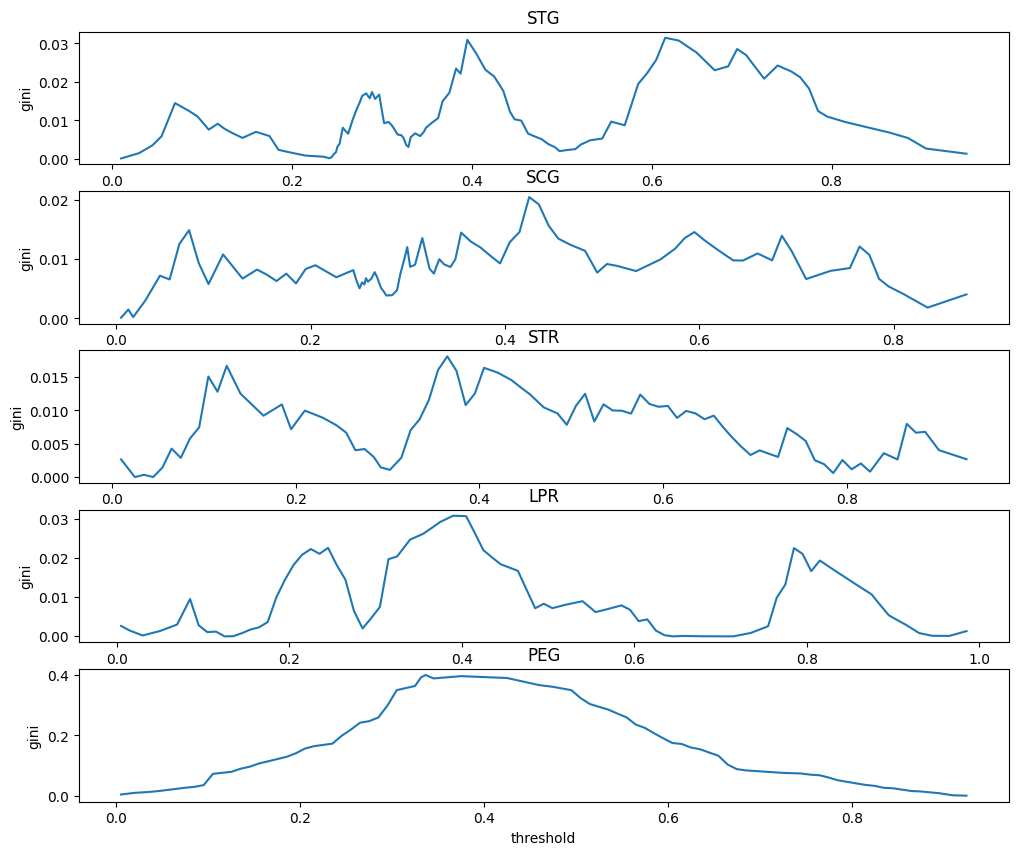

In [ ]:
plt.figure(figsize=(12,10))
i = 1
for feature in features:
  T, Q, best_t, best_q = find_best_split(df[feature], y, 'classification', 'real')
  plt.subplot(5, 1, i)
  plt.plot(T, Q)
  plt.title(feature)
  plt.xlabel('threshold')
  plt.ylabel('gini')
  i += 1
plt.show()




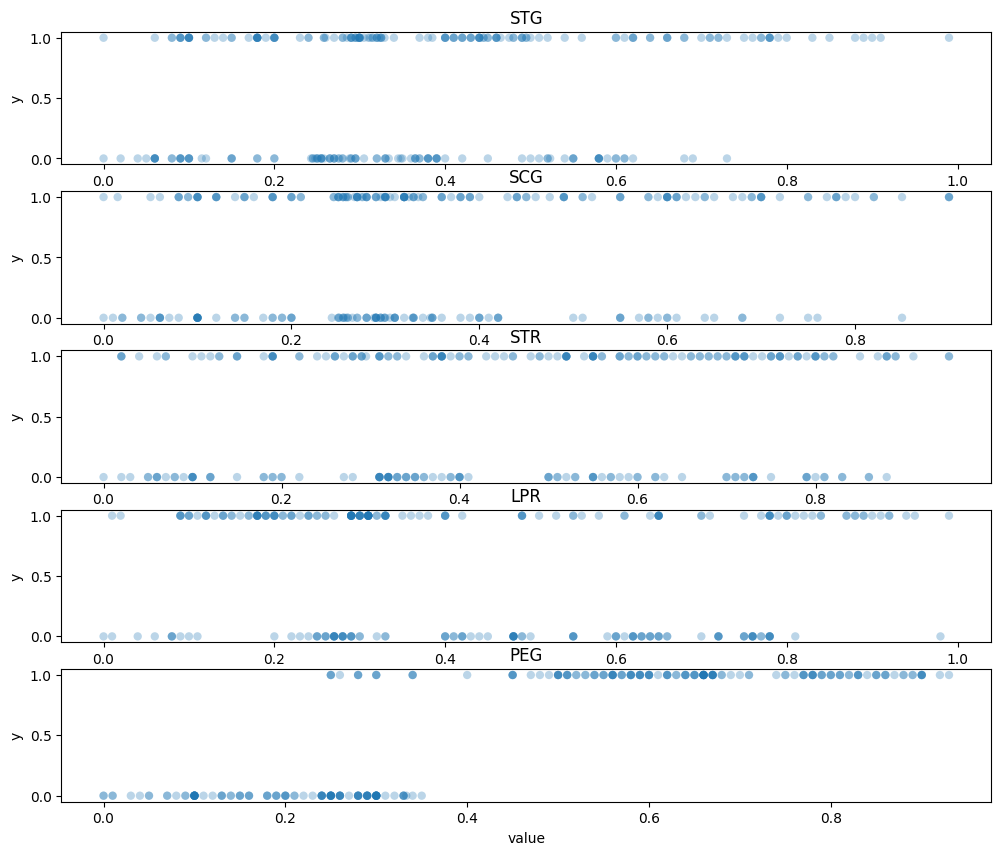

In [ ]:
plt.figure(figsize=(12, 10))
i = 1
for feature in features:
    plt.subplot(5, 1, i)
    plt.scatter(df[feature], y, alpha=0.3, edgecolors='none')
    plt.title(feature)
    plt.xlabel('value')
    plt.ylabel('y')
    i+=1
plt.show()

Протестируем дерево на датасете mushrooms

In [ ]:
!wget https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/homework/homework03/agaricus-lepiota.data .

--2026-04-17 17:04:42--  https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/homework/homework03/agaricus-lepiota.data
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 373704 (365K) [text/plain]
Saving to: ‘agaricus-lepiota.data’

agaricus-lepiota.da 100%[===================>] 364.95K  --.-KB/s    in 0.04s   

2026-04-17 17:04:42 (9.79 MB/s) - ‘agaricus-lepiota.data’ saved [373704/373704]

--2026-04-17 17:04:42--  http://./
Resolving . (.)... failed: No address associated with hostname.
wget: unable to resolve host address ‘.’
FINISHED --2026-04-17 17:04:42--
Total wall clock time: 0.2s
Downloaded: 1 files, 365K in 0.04s (9.79 MB/s)


In [ ]:
df = pd.read_csv('agaricus-lepiota.data', header=None)
df

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [ ]:
y = df[0]
y

,0
0,p
1,e
2,e
3,p
4,e
...,...
8119,e
8120,e
8121,e
8122,p


In [ ]:
df = df.drop(0, axis = 1)
df

,1,2,3,4,5,6,7,8,9,10,...,13,14,15,16,17,18,19,20,21,22
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,k,s,n,f,n,a,c,b,y,e,...,s,o,o,p,o,o,p,b,c,l
8120,x,s,n,f,n,a,c,b,y,e,...,s,o,o,p,n,o,p,b,v,l
8121,f,s,n,f,n,a,c,b,n,e,...,s,o,o,p,o,o,p,b,c,l
8122,k,y,n,f,y,f,c,n,b,t,...,k,w,w,p,w,o,e,w,v,l


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.to_numpy(), y.to_numpy(), train_size = 0.5, random_state = 67)

In [ ]:
x_train

array([['b', 'y', 'y', ..., 'k', 's', 'm'],
       ['f', 'f', 'n', ..., 'n', 'v', 'd'],
       ['x', 's', 'g', ..., 'n', 'v', 'd'],
       ...,
       ['x', 's', 'n', ..., 'w', 'c', 'w'],
       ['f', 'y', 'g', ..., 'h', 'v', 'd'],
       ['x', 's', 'g', ..., 'n', 's', 'g']], dtype=object)

In [ ]:
y_train

array(['e', 'e', 'p', ..., 'e', 'p', 'e'], dtype=object)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
model = DecisionTree(feature_types=['categorical']*22)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

1.0


Сделаем бэггинг

In [ ]:
!wget https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/homework/homework03/diabetes.csv .

--2026-04-17 17:05:25--  https://raw.githubusercontent.com/SergeyKorpachev/math-faculty-ml/refs/heads/main/2026/homework/homework03/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23873 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  23.31K  --.-KB/s    in 0.001s  

2026-04-17 17:05:25 (15.8 MB/s) - ‘diabetes.csv’ saved [23873/23873]

--2026-04-17 17:05:25--  http://./
Resolving . (.)... failed: No address associated with hostname.
wget: unable to resolve host address ‘.’
FINISHED --2026-04-17 17:05:25--
Total wall clock time: 0.2s
Downloaded: 1 files, 23K in 0.001s (15.8 MB/s)


In [ ]:
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

In [ ]:
data = pd.read_csv('diabetes.csv')
print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Посмотрим на распределение целевой переменной

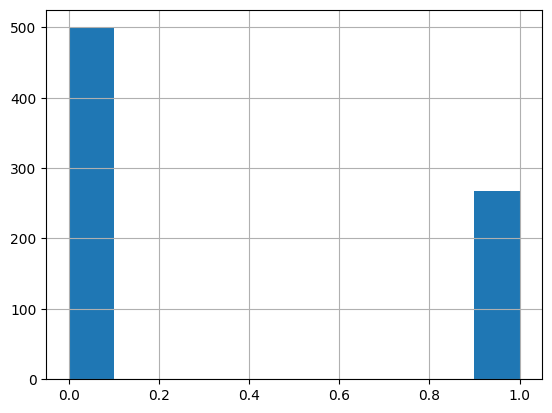

In [ ]:
data['Outcome'].hist()
plt.show()

In [ ]:
y = data['Outcome']
X = data.drop('Outcome', axis=1)

In [ ]:
X_train, x_test, Y_train, y_test = train_test_split(X, y, train_size = 0.7, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(X_train, Y_train, train_size = 0.7, random_state=42)

In [ ]:
max_depth = []
min_samples_leaf = []
for i in range(5, 120, 5):
  max_depth.append(i)
for i in range(1, 20):
  min_samples_leaf.append(i)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score

In [ ]:
bestf1 = 0
for i in max_depth:
  for j in min_samples_leaf:
    model = DecisionTreeClassifier(max_depth = i, min_samples_leaf = j, random_state=42)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_val)
    f1 = f1_score(y_val, y_pred)
    if f1 > bestf1:
      bestf1 = f1
      best_max_d = i
      best_min_s = j
print(bestf1, best_max_d, best_min_s)

0.6730769230769231 5 6


In [ ]:
model = DecisionTreeClassifier(max_depth = 5, min_samples_leaf = 6, random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred)
print(accuracy, precision, recall, auc_roc)

0.7532467532467533 0.6666666666666666 0.575 0.711341059602649


In [ ]:
model = BaggingClassifier(n_estimators = 50, random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred)
print(accuracy, precision, recall, auc_roc)

0.7489177489177489 0.6309523809523809 0.6625 0.7286009933774835


In [ ]:
max_depth = []
min_samples_leaf = []
for i in range(5, 120, 5):
  max_depth.append(i)
for i in range(1, 20):
  min_samples_leaf.append(i)

In [ ]:
gs = GridSearchCV(RandomForestClassifier(n_estimators = 50, random_state=42), {'max_depth': max_depth, 'min_samples_leaf': min_samples_leaf}, cv = 5, scoring = 'f1')
gs.fit(X_train, Y_train)
print(gs.best_params_)

{'max_depth': 15, 'min_samples_leaf': 5}


In [ ]:
model = RandomForestClassifier(n_estimators = 50, max_depth = 15, min_samples_leaf = 5, random_state=42)
model.fit(X_train, Y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred)
print(accuracy, precision, recall, auc_roc)

0.7532467532467533 0.6352941176470588 0.675 0.7348509933774835


1 0.6509933774834438
6 0.7800082781456954
11 0.7980132450331126
16 0.799296357615894
21 0.7956539735099337
26 0.7895695364238411
31 0.7927152317880795
36 0.7932119205298014
41 0.7989238410596027
46 0.800703642384106
51 0.7989652317880795
56 0.8012003311258279
61 0.8023592715231788
66 0.803228476821192
71 0.8023592715231789
76 0.8018211920529802
81 0.8023592715231788
86 0.8036837748344371
91 0.8031043046357614
96 0.8057533112582783
101 0.8061258278145695
106 0.8078642384105961


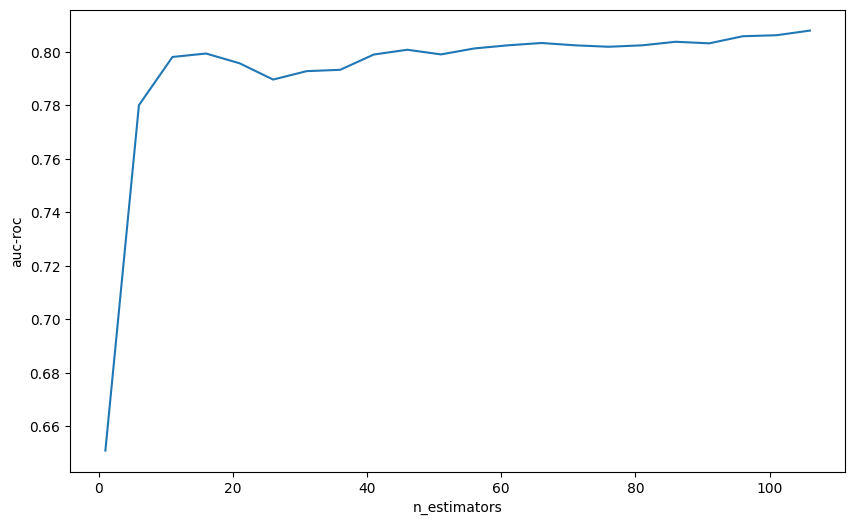

In [ ]:
n_estim = []
for i in range(1, 110, 5):
  n_estim.append(i)
auc_scores = []
for n in n_estim:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, Y_train)
    y_probs = model.predict_proba(x_test)[:, 1]
    auc = roc_auc_score(y_test, y_probs)
    auc_scores.append(auc)
    print(n, auc)
plt.figure(figsize=(10, 6))
plt.plot(n_estim, auc_scores)
plt.xlabel('n_estimators')
plt.ylabel('auc-roc')
plt.show()

In [ ]:
model = RandomForestClassifier(n_estimators = 50, max_depth = 15, min_samples_leaf = 5, random_state=42)
model.fit(X_train, Y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=5, n_estimators=50,
                       random_state=42)

In [ ]:
important = model.feature_importances_

In [ ]:
names = X.columns

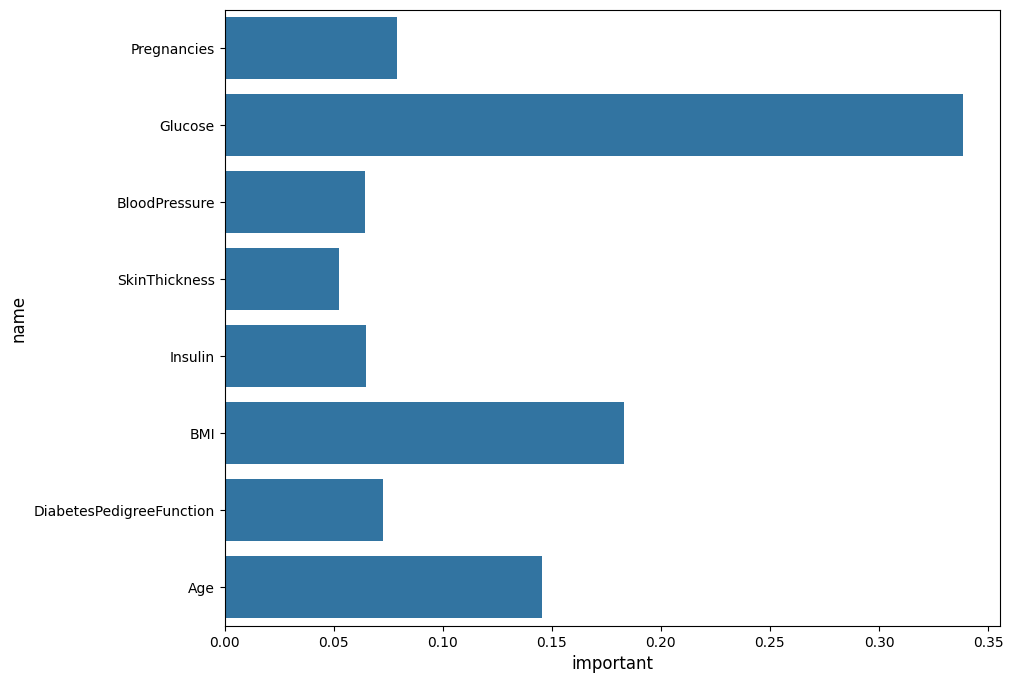

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(x=important, y=names)
plt.xlabel('important', fontsize=12)
plt.ylabel('name', fontsize=12)
plt.show()

Самый важный признак Glucose